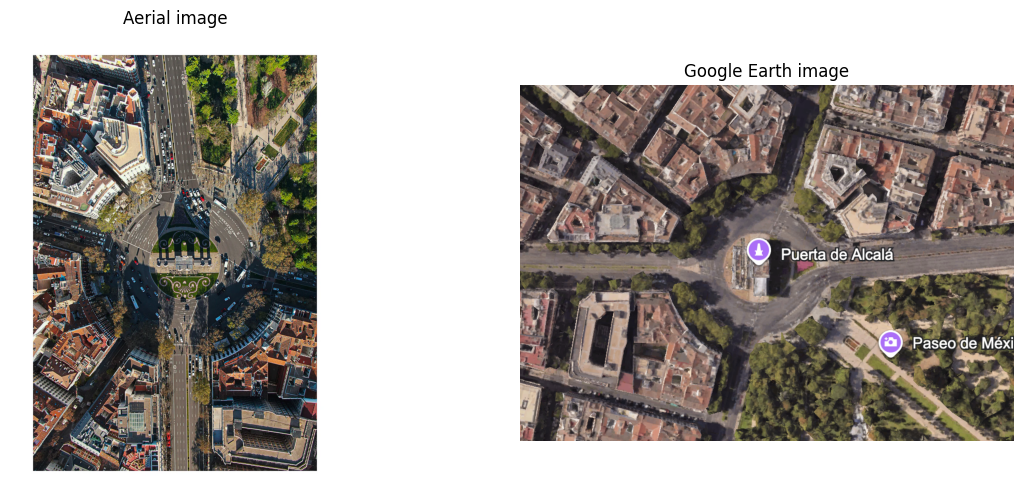

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

drone_path = Path("../data/drone.webp")
sat_path = Path("../data/satellite.png")  # change to .jpg if your file is satellite.jpg

drone = cv2.imread(str(drone_path))
sat = cv2.imread(str(sat_path))

assert drone is not None, f"Could not load {drone_path}"
assert sat is not None, f"Could not load {sat_path}"

drone_rgb = cv2.cvtColor(drone, cv2.COLOR_BGR2RGB)
sat_rgb = cv2.cvtColor(sat, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(drone_rgb)
plt.title("Aerial image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sat_rgb)
plt.title("Google Earth image")
plt.axis("off")

plt.show()

In [2]:
gray_drone = cv2.cvtColor(drone, cv2.COLOR_BGR2GRAY)
gray_sat = cv2.cvtColor(sat, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray_drone, None)
kp2, des2 = sift.detectAndCompute(gray_sat, None)

print("Aerial image keypoints:", len(kp1))
print("Google Earth keypoints:", len(kp2))

Aerial image keypoints: 16041
Google Earth keypoints: 9579


In [3]:
bf = cv2.BFMatcher(cv2.NORM_L2)

matches = bf.knnMatch(des1, des2, k=2)

good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good matches:", len(good_matches))

Good matches: 99


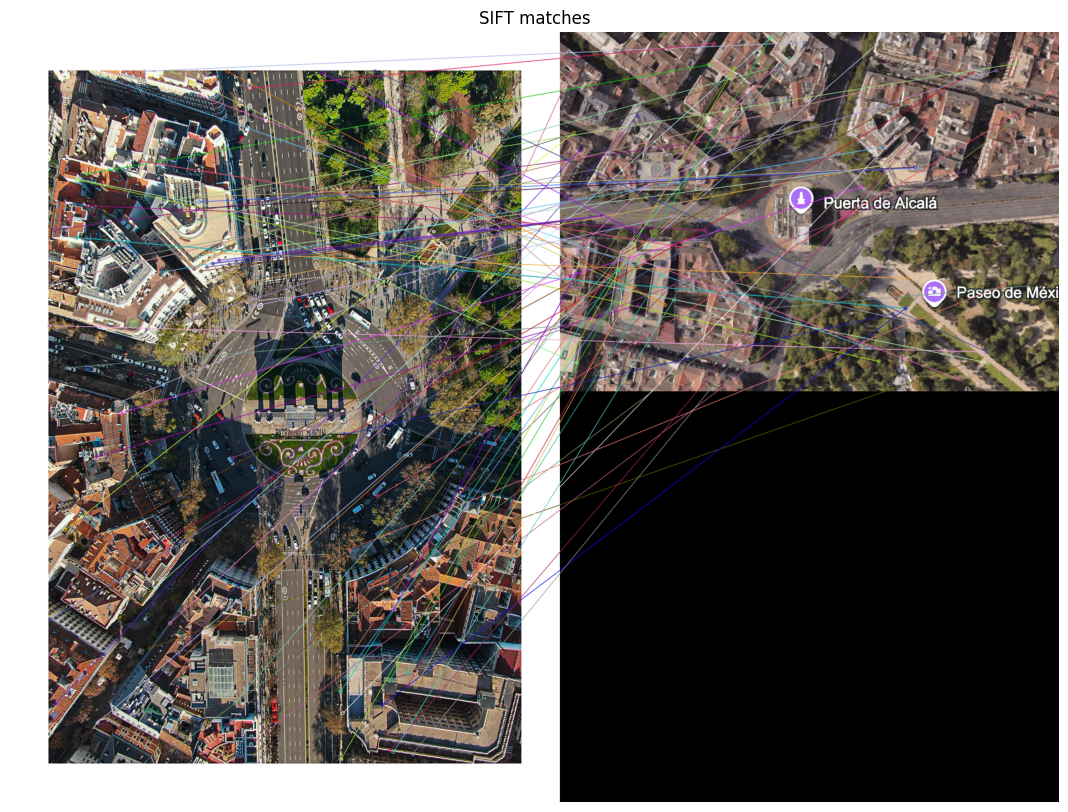

In [4]:
match_img = cv2.drawMatches(
    drone_rgb,
    kp1,
    sat_rgb,
    kp2,
    good_matches[:80],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

plt.figure(figsize=(20, 10))
plt.imshow(match_img)
plt.title("SIFT matches")
plt.axis("off")
plt.show()

In [5]:
if len(good_matches) >= 4:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    print("Homography:")
    print(H)

    inliers = int(mask.ravel().sum())
    print("Inliers:", inliers)
    print("Inlier ratio:", inliers / len(good_matches))
else:
    H = None
    mask = None
    print("Not enough matches.")

Homography:
[[ 2.24185328e-01 -1.38451075e+00  7.77785626e+02]
 [ 1.96368580e-01 -4.96539235e-01  2.44284786e+02]
 [ 3.96328501e-04 -1.71821269e-03  1.00000000e+00]]
Inliers: 7
Inlier ratio: 0.0707070707070707


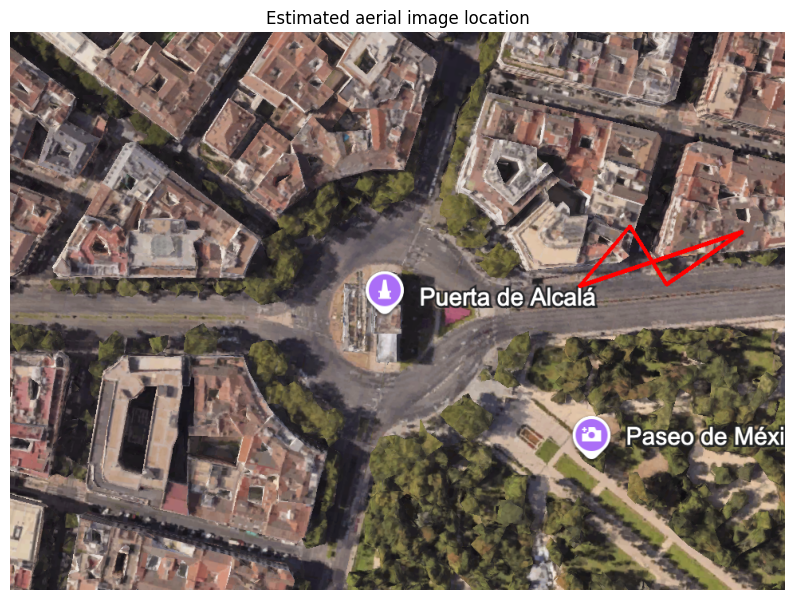

In [6]:
if H is not None:
    h, w = drone_rgb.shape[:2]

    corners = np.float32([
        [0, 0],
        [w, 0],
        [w, h],
        [0, h],
    ]).reshape(-1, 1, 2)

    projected_corners = cv2.perspectiveTransform(corners, H)

    sat_with_box = sat_rgb.copy()
    sat_with_box = cv2.polylines(
        sat_with_box,
        [np.int32(projected_corners)],
        isClosed=True,
        color=(255, 0, 0),
        thickness=4,
    )

    plt.figure(figsize=(10, 10))
    plt.imshow(sat_with_box)
    plt.title("Estimated aerial image location")
    plt.axis("off")
    plt.show()

In [7]:
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

cv2.imwrite("../outputs/sift_matches.jpg", cv2.cvtColor(match_img, cv2.COLOR_RGB2BGR))

if H is not None:
    cv2.imwrite("../outputs/estimated_location.jpg", cv2.cvtColor(sat_with_box, cv2.COLOR_RGB2BGR))

print("Saved outputs to outputs/")

Saved outputs to outputs/
